In [33]:
import os
import sys
import io
import warnings
import yaml  # kalibrace kamery
from ipywidgets import interact, interactive, fixed, interact_manual  # slidery na segmentaci

import ipywidgets as widgets
from IPython.display import display

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
from PIL import Image
from skimage import feature, color, transform

from improutils import *

warnings.filterwarnings('ignore')
%matplotlib inline
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

<Token var=<ContextVar name='format_options' default={'edgeitems': 3, 'threshold': 1000, 'floatmode': 'maxprec', 'precision': 8, 'suppress': False, 'linewidth': 75, 'nanstr': 'nan', 'infstr': 'inf', 'sign': '-', 'formatter': None, 'legacy': 9223372036854775807, 'override_repr': None} at 0x000001E555613BA0> at 0x000001E50BD45740>

## Dokumentace

- Pomocí `jmeno_funkce?` v Jupyter Notebooku
- [Improutils - FIT Gitlab](https://gitlab.fit.cvut.cz/bi-svz/improutils_package)
- [Improutils - Github](https://github.com/ImprolabFIT/improutils_package)
- [OpenCV](https://docs.opencv.org/4.x/)
- [HSV](https://www.rapidtables.com/web/color/color-picker.html)

## Popis snímací soustavy

- kamera
- objektiv
- světlo

Pracovní vzdálenost (okraj objektivu - povrch objektu)
- vs. minimální pracovní vzdálenost objektivu

### Kamera
- fyzická velikost senzoru (např. `1/1.8"`, 1" = 16 mm, měřeno na diagonále)
- -> velikost pixelu, mm/px; **přesnost** = dvojnásobek velikosti pixelu
- https://www.baslerweb.com/en/shop/aca1920-40uc/
  - 1/1.2" Sensor Format
  - 11.33 mm × 7.13 mm Sensor size
  - 1920 px × 1200 px
- https://www.baslerweb.com/en/shop/aca2500-14gm/
    - 1/2.5" Sensor Format
    - 5.7 mm × 4.28 mm Sensor size
    - 2592 px × 1944 px
- https://www.baslerweb.com/en/shop/aca2500-60um/
   - 1" Sensor Format
   - 2590x2048
   - 12.44 mm × 9.83 mm
      

### Objektiv
- ohnisková vzdálenost (např. `f = 8 mm`, v průmyslu většinou pevná)
- rozsah clony (např. `F 1.4 - 16.0`), podíl ohniskové vzdálenosti a průměru otvoru clony
- fyzická velikost objektivu (např. `1/1.8"` nebo `7,2 x 5,4 mm`), **větší nebo rovna velikosti senzoru**

- https://lenses.kowa-usa.com/6mp-plus-sc-series/1243-lm50sc.html
    - f=50
    - image_size=1"
    - ostřící kroužek a kroužek pro nastavení clony (iris):
    - Ostřící kroužek
        - **Název**: Minimum Focus Distance
        - **Rozsah hodnot**: 0.3m až nekonečno
    - Kroužek pro nastavení clony (iris)
        - **Název**: Iris Range (F-Stop)
        - **Rozsah hodnot**: F2.0 až F16
- https://lenses.kowa-usa.com/6mp-plus-sc-series/1242-lm35sc.html
    - Image Size	1" (12.8 x 9.6 x 16mm)
    - f=35mm
    - Iris Range (F-Stop) F2.0 - F16
    - Minimum Focus Distance 0.2m
    - Mount	C-Mount

### Nasvícení
- Směrové... soustředí se přímo na objekt, rovnoběžné paprsky
    - **zvýraznění reliéfu**
- Difúzní/rozptýlené světlo... nepřímé
    - často jako diuzor přes klasické (přímé) světlo
    - **skrytí reliéfu**
- Zadní... použití pro maximální **zvýraznění obrysu**
    - se silným difuzorem
- Dark Field... velké množství LED diod okolo objektu, svítí pod ostrým bočním úhlem
    - **velké zvýraznění reliéfu**, vyrytých/vytlačených nápisů atd.
- Kopulové... Opak dark fieldu, světlo přichází ze všech stran, rovnoměrně
    - **maximální skrytí reliéfu**
- *Koaxiální*... díky propustnému zrcadlu světlo ze stejného směru, jako kamera
    - DOAL = Diffused On Axis Light

## Výběr kamery, objektivu

Kamera:
- velikost objektu (v nějakém rozmezí)
- požadovaná **přesnost** obrazu/rozlišení

Objektiv:
- velikost objektu (v nějakém rozmezí, bereme max)
- pracovní vzdálenost (v nějakém rozmezí)
- velikost snímacího čipu
- kompatibilita s kamerou (stejný závit, větší nebo stejná velikost objektivu oproti snímači)

### Vyber kamery a objektivu

In [5]:
# max_object_size = 200 #mm delsi strana
# max_deviation = 0.3 #mm

#choose camera
def min_resolution(max_object_size, max_deviation): # na delsi strane
    return 2.2*max_object_size/max_deviation

# print(f"min_resolution {min_resolution(max_object_size, max_deviation)} px")
# picked 1626x1236px , 1/1.8, 7.2x5.4mm
# px = 1626
# cam_chip_size = 7.2 #mm delsi strana
# dst_min = 200 #mm
# dst_max = 600

def real_max_deviation(max_object_size, px): #přesnost/accuracy
    return 2.2*max_object_size/px
    
# print(f"real_max_deviation {real_max_deviation(max_object_size, px)} mm")

#choose lens
def focal_len(cam_chip_size, dst_min, dst_max, object_size):
    return (cam_chip_size * dst_min / (1.1 * object_size), cam_chip_size * dst_max / (1.1 * object_size))

# print(f"focal_len {focal_len(cam_chip_size, dst_min, dst_max, max_object_size)} mm")
#picked from this interval - 2/3, F1.4-F1.6, f 16mm
# f = 16 #mm 
# lens_len = 28.2 #mm

def placement(f, object_size, cam_chip_size, lens_len):
    return f*1.1*object_size/cam_chip_size + lens_len

# print(f"placement {placement(f,max_object_size, cam_chip_size, lens_len)} mm")


gain - zesileni sniamce, +=zvysuje jas a sum

exposure time - doba po kterou dopada svetlo na snimac, += zachyti vice svetla, rozmazani pohybujicich objektu

white balance - vyvazeni bile barvy, spravne nastavit podle okolnich svetel

clona - otvor skrz ktery dopada svetlo na snimac, -= více svetla, rozmazani pozadi, += vice detailu

zaverka - otevira snimac pro expozici svetla, rychla=rychle pohyby

## Optické vady (03)

- Vinětace
- Chromatická aberace
- Difrakce
- Distorze

### Vinětace
tmavé rohy obrázku, do rohů senzoru nedopadá dostatek světla (oproti středu)

Příčiny:
- konstrukce objektivu (příliš úzký)
- příliš **otevřená** clona

Řešení:
- vyměnit objektiv za širší
- uzavřít clonu

### Chromatická aberace
barevné lemování hran

Příčiny:
- konstrukce čočky objektivu
- příliš **otevřená** clona

Řešení:
- vyměnit objektiv (jiný materiál čočky, menší zoom)
- uzavřít clonu

### Difrakce
snížení ostrosti obrazu, zrnitost
- obecný problém průchodu vlnění úzkou štěrbinou
- [Difrakce (Wikipedia)](https://cs.wikipedia.org/wiki/Difrakce)

Příčiny:
- příliš **uzavřená** clona

Řešení:
- nastavit clonu na **sweet-spot** (omezení všech vad optiky)

### Distorze
Zakřivení čar, které jsou v realitě rovné
- zejména u **širokoúhlých objektivů**
- **radiální** distorze... barrel/pincushion
- **tangenciální**... "naklonění" obrazu, jedna strana blíže než druhá

Řešení:
- výměna objektivu
- digitální **kalibrace** obrazu

Kalibrace:
- na základě snímků referenčního obrazu (šachovnice známých rozměrů)
- ztrátová... odříznutí zakřiveného obrazu v krajích
- formálně... nalezení kalibračních parametrů
	- $k_{1:3}$ pro radiální
	- $p_{1:2}$ pro tangenciální

## Kalibrace kamery (03)

Nafotit cca 20 snímků šachovnice, pod různými úhly a v různých částech obrazu

In [2]:
def reindex_image_files(source_dir, output_dir=None):
    """ Reads all images in source_dir and based on they original order, 
    change their filename to be continuous integer (starting from 0). 
    Then, they can be easily read by cv2.VideoCapture. Image format is kept.
    
    Parameters
    ----------
    source_dir : string
        Input images directory that have to be renamed.
    output_dir : Optional[string]
        Output directory for renamed files. If not specified, renaming is done inplace in source_dir.
    Returns
    -------
    None
    """
    input_files = []
    
    for file in os.listdir(source_dir):
        if re.match(r'.*(\.bmp|\.jpg|\.png|\.gif)$', file, re.I):
            input_files.append(os.path.join(source_dir, file))

    if not input_files:
        print('No files were found.')
        return
    
    extension = '.' + input_files[0].split(".")[-1]
    if output_dir is None:
        for i, filename in enumerate(sorted(input_files)):  # originally... natsorted (but order doesn't matter)
            os.rename(filename, os.path.join(source_dir, str(i) +  extension))
        print(f'Files within {source_dir} were renamed, starting from 0{extension} to {i}{extension}.')
    else:
        if not os.path.isdir(output_dir):
            os.mkdir(output_dir)

        for i, filename in enumerate(sorted(input_files)):  # originally... natsorted
            shutil.copy(filename, os.path.join(output_dir, str(i) + extension))
            
        print(f'Files from {source_dir} were renamed and saved to {output_dir}, starting from 0{extension} to {i}{extension}.')


def create_file_path(folder, file_name):
    '''Easier defined function to create path for filename inside a folder.

    Parameters
    ----------
    folder : string
        Base folder directory in string notation.
    file_name : string
        File name that should be inside the base folder.
    Returns
    -------
    string
        Path to the newly created file.
    """
    '''
    if not os.path.isdir(folder):
        os.mkdir(folder)

    return os.path.join(folder, file_name)

def camera_calib(input_source, chess_shape, output_calib_file=None, img_show_delay=1):
    """ Browses all images found in input_source and on each image tries to find chessboard corners.
    If chessboard corners are found, image corespondences with real world space are added to lists.
    Based on these image-world corespondences, camera calibration is made.

    Parameters
    ----------
    input_source : string
        Input source for cv2.VideoCapture (could be camera source or sequence of saved images where format has to be specified).
    chess_shape : tuple
        Number of inner corners per a chessboard row and column.
    output_calib_file : Optional[string]
        Output file where calibration is saved when neccesary.
    img_show_delay : int
        Delay in ms between shown images.
    Returns
    -------
    tuple
        camera matrix and distance coefficients
    """

    cap = cv2.VideoCapture(input_source)

    if not cap.isOpened():
        cv2.destroyAllWindows()
        raise FileNotFoundError('Capture cannot be opened.')

    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
    objp = np.zeros((chess_shape[0] * chess_shape[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:chess_shape[0], 0:chess_shape[1]].T.reshape(-1, 2)

    # Arrays to store object points and image points from all the images.
    objpoints = []  # 3d point in real world space
    imgpoints = []  # 2d points in image plane.

    cntr = 0
    good_images = []

    while cap.isOpened():
        print(f"Img {cntr} is being processed..")
        cntr += 1
        ret, frame = cap.read()
        if not ret: break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # If found, add object points, image points (after refining them)
        ret, corners = cv2.findChessboardCorners(gray, chess_shape)

        if ret:
            objpoints.append(objp)
            corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1),
                                       (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.1))
            imgpoints.append(corners)

            # Draw and display the corners
            frame = cv2.drawChessboardCorners(frame, chess_shape, corners, ret)
            good_images.append(frame)

    print(f'{len(good_images)} from {cntr} frames were correctly detected.')
    plot_images(good_images[0])
    print('Computing camera matrix...')
    rms, camera_matrix, dist_coefs, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None,
                                                                       None)

    if output_calib_file is not None:
        save_camera_calib(output_calib_file, camera_matrix, dist_coefs)

    print('\nRMS:', rms)
    print('Camera matrix:\n', camera_matrix)
    print('Distortion coefficients: ', dist_coefs.ravel())

    return camera_matrix, dist_coefs, good_images


def correct_frame(frame, camera_matrix, dist_coeffs):
    """Returns undistorted frame."""
    return cv2.undistort(frame, camera_matrix, dist_coeffs)


IDX_CAM_MATRIX = "camera_matrix"
IDX_DIST_COEFFS = "dist_coefs"

def load_camera_calib(input_file):
    """ Loads camera calibration from specified input file.
    
    Parameters
    ----------
    input_file : string
        Input file with calibration data in YAML format.
    Returns
    -------
    tuple(np.array, np.array)
        Returns a tuple where first element is camera matrix array and second element is dist coefficients array. 
        These arrays might be empty if the file isn't found or in correct format.
    """
    try:
        import builtins
        with builtins.open(input_file, 'r') as stream:
            data = yaml.load(stream)
            return data[IDX_CAM_MATRIX], data[IDX_DIST_COEFFS]
    except (FileNotFoundError, yaml.YAMLError) as exc:
        print(f'File {input_file} couldn\'t be read.')
        return np.array([]), np.array([])


#pouzite v camera_calib
def save_camera_calib(output_file, camera_matrix, dist_coefs):
    """ Saves camera calibration to specified output file.

    Parameters
    ----------
    output_file : string
        Output file used for storing calibration data in YAML format. Parent directory is created if needed.
    Returns
    -------
    None
    """
    data = {IDX_CAM_MATRIX: camera_matrix, IDX_DIST_COEFFS: dist_coefs}
    output_dir = os.path.dirname(output_file)

    if not os.path.isdir(output_dir):
        os.mkdir(output_dir)
    import builtins
    with builtins.open(output_file, "w") as f:
        yaml.dump(data, f)


### Použití

Číslice z `reindex_image_files` na cviku lezly bez počáteční nuly, proto `%01d`. Jinak přepsat na `%02d`.

Výstup:

```
Img 0 is being processed..
...
Img 18 is being processed..
13 from 19 frames were correctly detected.
Computing camera matrix...

RMS: 0.9061767971034758
Camera matrix:
 [[2760.471 0.000 919.260]
 [0.000 2761.918 607.532]
 [0.000 0.000 1.000]]
Distortion coefficients:  [-0.153 0.553 0.004 -0.007 0.838]
```

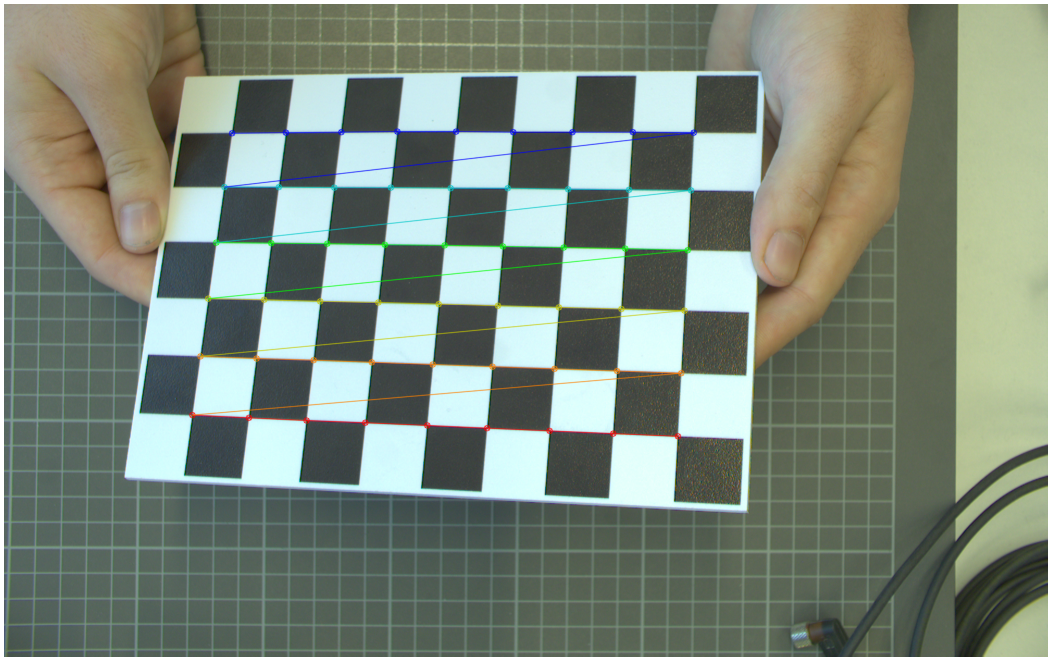

## MERENI VELIKOSTI

#### ggray

### HSV

## mereni cviko obedlniky

## lentilky pocitani

In [43]:
def find_thresholds(h_range, s_range, v_range):
    """ Funkce je vstupem pro funkci multicolor_segmentation, neměňte její syntaxi """
    
    lower_bound=(to_intensity(h_range[0]), s_range[0], v_range[0]) ###
    upper_bound=(to_intensity(h_range[1]), s_range[1], v_range[1]) ###
    
    image = to_hsv(image_bgr) 
    mask = segmentation_two_thresholds(image,lower_bound,upper_bound) ###
    
    plot_images(mask, apply_mask(image_bgr, mask), titles=['Applied mask', 'Mask'])

#colors = ['green', 'blue', 'purple', 'yellow', 'orange', 'pink', 'red']
#color_thresholds = multicolor_segmentation(find_thresholds,colors)

In [44]:
#color=='blue':
def algorithm(img, color):
    
    ### Převod do některého z barevných prostorů
    img_hsv = to_hsv(img)

    ### Segmentace podle barvy
    lower_bound=(to_intensity(160), 46, 0) ###
    upper_bound=(to_intensity(210), 255, 214)
    mask_bin = segmentation_two_thresholds(img_hsv, lower_bound, upper_bound) ###
    
    res = apply_mask(img, mask_bin)
    
    return res, mask_bin

In [45]:
def count_objects(mask):
    
    min_area, max_area = 100, 100000 ###
    _, count, _ = find_contours(mask,min_area, max_area) ###
    return count

## Segmentace, kontury

Relevatntní funkce:
- `segmentation_two_thresholds`
- `segmentation_auto_threshold`

Hledání kontury:
- `cv2.dilate` [doc](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)
- `cv2.erode`
- `fill_holes`
- `find_contours` -> `(contour_drawn: np.ndarray, count: int, contours: list)`

`enum_contours`

Převod na geometrický útvar:
- `cv2.minAreaRect` -> `(center(x, y), (width, height), angle of rotation)` [guide](https://theailearner.com/tag/cv2-minarearect/)
- `cv2.boundingRect` kolmý na osy x, y
- `cv2.minEnclosingCircle` -> `(center, radius)`

## Objektové charakteristiky, klasifikace (12)

- Formfactor (špičatost)
- Roundness (kulatost)
- Aspect Ratio (poměr stran)
- Convexity (konvexita, vypouklost)
- Solidity (plnost, celistvost)
- Compactness (kompaktnost, hutnost)
- Extent (dosah, rozměrnost)

In [50]:
def segment_object(image, background):
    image = to_gray(image)
    mask = cv2.bitwise_xor(image, background)
    mask = segmentation_one_threshold(mask, 100)
    plot_images(mask)
    
    image, cnt, contour = find_contours(mask, min_area=100, max_area= 1000000)
    print(cnt)
    return image, contour

#fotit backlightem
# image = load_image("data/object.bmp")
# background = load_image("data/background.bmp")
# mask = to_gray(background)

# binary_object, cont = segment_object(image, mask)
# plot_images(binary_object)

## Vzdálenosti objektů

- `cv2.minAreaRect` -> `(center(x, y), (width, height), angle of rotation)` [guide](https://theailearner.com/tag/cv2-minarearect/)
- `cv2.minEnclosingCircle` -> `(center, radius)`
- následující custom funkce pro vzdálenosti

`enum_contours` !

In [51]:
def line_segment_to_point_dist(l_pt1: tuple, l_pt2: tuple, dst_pt: tuple):
    # výpočet vzdálenosti mezi úsečkou a bodem
    
    # https://stackoverflow.com/questions/849211/shortest-distance-between-a-point-and-a-line-segment
    # https://courses.fit.cvut.cz/BI-LA2/@master/textbook/sec-vzdalenost-od-podprostoru.html
    l_pt1 = np.array(l_pt1)
    l_pt2 = np.array(l_pt2)
    dst_pt = np.array(dst_pt)

    line_vec = l_pt2 - l_pt1
    coef = np.dot(line_vec, dst_pt - l_pt1) / np.linalg.norm(line_vec) ** 2

    if coef < 0:
        projection = l_pt1
        # print("case 1")
    elif coef > 1:
        projection = l_pt2
        # print("case 2")
    else:
        projection = l_pt1 + (coef * line_vec)
        # print("case 3")

    return np.linalg.norm(dst_pt - projection)

In [52]:
def line_segments_dist(l1_pt1, l1_pt2, l2_pt1, l2_pt2):
    # výpočet vzdálenosti mezi úsečkami
    
    # min of distance from the two edges of l2
    return min( line_segment_to_point_dist(l1_pt1, l1_pt2, l2_pt1),
                line_segment_to_point_dist(l1_pt1, l1_pt2, l2_pt2),
                line_segment_to_point_dist(l2_pt1, l2_pt2, l1_pt1),
                line_segment_to_point_dist(l2_pt1, l2_pt2, l1_pt2))

In [53]:
def rect_dist(r1_pts, r2_pts):
    # výpočet vzdálenosti mezi dvěma obdélníky
    
    r1_lines = [(r1_pts[0], r1_pts[1]), (r1_pts[1], r1_pts[2]), (r1_pts[2], r1_pts[3]), (r1_pts[3], r1_pts[0])]
    r2_lines = [(r2_pts[0], r2_pts[1]), (r2_pts[1], r2_pts[2]), (r2_pts[2], r2_pts[3]), (r2_pts[3], r2_pts[0])]

    dist = np.inf
    for l1 in r1_lines:
        for l2 in r2_lines:
            dist = min(dist, line_segments_dist(*l1, *l2))

    return dist

In [54]:
def rect_point_dist(r1_pts, r2_pt):
    # výpočet vzdálenosti bodu od obdélníku
    
    r1_lines = [(r1_pts[0], r1_pts[1]), (r1_pts[1], r1_pts[2]), (r1_pts[2], r1_pts[3]), (r1_pts[3], r1_pts[0])]

    dist = np.inf
    for l1 in r1_lines:
        dist = min(dist, line_segment_to_point_dist(*l1, r2_pt))

    return dist

In [55]:
def enum_contours(img: np.ndarray, contours: list) -> None:
    """Take contours (as given from find_contours), calculate minAreaRect
    and write the index label on the center of the image. Plot this labeled image.
    """
    img_labels = img.copy()

    for idx, cont in enumerate(contours):
        rect = cv2.minAreaRect(np.array(cont))

        # center of the object
        coords = np.array(rect[0], dtype=int)
        print(f"draw {idx} -> {coords}")
    
        cv2.putText(img_labels, str(idx), coords, 0, 8., (255, 0, 0), 10)
    
    plot_images(img_labels)

### Použití

## Prace se segmentaci

### p seg


obsah

Výpočet středu (centroidu)

kruh

segmentace obrysu  bez backlightu

### rotace

In [5]:
def rotate_contour(contour, angle, center):
    """ Otočí konturu o daný úhel (ve stupních) kolem zvoleného středu po smeru hodinovych rucicek"""
    angle_rad = np.radians(angle)  # Převod úhlu na radiány
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

    # Aplikujeme rotační matici na všechny body kontury
    rotated = []
    for point in contour[:, 0, :]:  # Pro každý bod v kontuře
        x, y = point
        x_new = center[0] + (x - center[0]) * cos_a - (y - center[1]) * sin_a
        y_new = center[1] + (x - center[0]) * sin_a + (y - center[1]) * cos_a
        rotated.append([x_new, y_new])

    return np.array(rotated, dtype=np.int32).reshape(-1, 1, 2)

### okoli

### vzd